# Editing Objects

This notebook lets you view generated captions when editing objects in an image for a single example, instead of having to run the entire sweep in `sec4__edit_objects_heatmap.py`. 

In [1]:
# load model and set up lens 
import torch 
from nnsight import VisionLanguageModel 
from sec3__object_detection import build_ocr_lens, prep_inputs

# model_name = "Qwen3-VL-2B-Instruct"; K = 45; rank = 219
model_name = "Qwen3-VL-8B-Instruct"; K = 115; rank = 463
model = VisionLanguageModel(f"Qwen/{model_name}", device_map="cuda", dispatch=True)

ranking_path = "../results/score_ocr_heads/{model_name}/final_1024.pt".format(model_name=model_name)

ocr_lens = build_ocr_lens(model, ranking_path, K)
ocr_lens.shape

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

torch.Size([4096, 4096])

In [3]:
def dec(t):
    return model.tokenizer.decode(t)

In [4]:
# get the low-rank pseudo-inverse version of the lens 
U, Sigma, Vh = torch.linalg.svd(ocr_lens.float())
trunc_ocr_lens = (U[:, :rank] * Sigma[:rank]) @ Vh[:rank, :]
pinv_ocr_lens = torch.linalg.pinv(trunc_ocr_lens.float()).bfloat16()

In [5]:
# just confirming that this rank is 60% of the lens energy
total = torch.square(Sigma).sum(dim=-1)
print(f"{(torch.square(Sigma[:rank]).sum(dim=-1) / total).item():.1%} of lens energy")

60.6% of lens energy


In [6]:
def generate_subbed(inp, mode, from_layer, until_layer, scale_new, remove_str=" motorcycle", add_str=" dog", pinv_ocr_lens=pinv_ocr_lens):
    img_pad_id = model.processor.tokenizer.convert_tokens_to_ids("<|image_pad|>")
    img_tok_mask = inp["input_ids"] == img_pad_id # each img is different n pad tokens 

    remove_tok = model.tokenizer(remove_str)['input_ids'][0]
    add_tok = model.tokenizer(add_str)['input_ids'][0]

    remove_u = model.lm_head.weight[remove_tok]
    add_u = model.lm_head.weight[add_tok]

    with model.generate(**inp, max_new_tokens=300, do_sample=False):
        for layer in range(from_layer, until_layer): # all layers
            img_states = model.model.language_model.layers[layer].input[img_tok_mask].save()

            if mode=="none":
                pass 
            elif mode=="raw_replace_tok":
                scalars_per_tok = (img_states @ remove_u) / (remove_u @ remove_u)
                img_states = img_states - scalars_per_tok[:, None] * remove_u
                img_states = img_states + scalars_per_tok[:, None] * scale_new * add_u
            elif mode=="ocr_replace_tok":
                remove_v = pinv_ocr_lens @ remove_u 
                add_v = pinv_ocr_lens @ add_u 
                scalars_per_tok = (img_states @ remove_v) / (remove_v @ remove_v)
                img_states = img_states - scalars_per_tok[:, None] * remove_v
                img_states = img_states + scalars_per_tok[:, None] * scale_new * add_v
            elif mode=="destroy":
                img_states = torch.randn_like(img_states)

            model.model.language_model.layers[layer].input[img_tok_mask] = img_states
        
        out = model.generator.output.save()

    print(model.tokenizer.decode(out)[0])

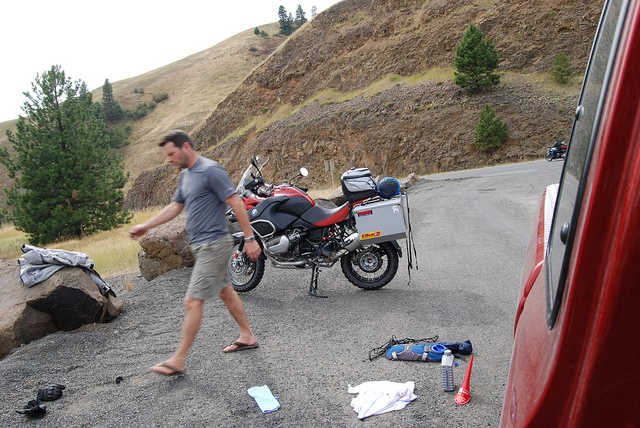

In [9]:
from PIL import Image 

img = Image.open("../images/motorcycle_131804.png")
img

In [ ]:
FROM_LAYER = 0
UNTIL_LAYER = model.config.text_config.num_hidden_layers
SCALE_NEW = 0.8 # how strongly is "dog" added? 

# NOTE: for this intervention to work, REM_TOK should be something that is actually
# in the image; otherwise, \lambda will be close to 0 and nothing will happen! 
REM_TOK = model.tokenizer(" motorcycle", add_special_tokens=False)['input_ids'][0]
ADD_TOK = model.tokenizer(" dog", add_special_tokens=False)['input_ids'][0]
print(f"Replacing {repr(dec(REM_TOK))} with {repr(dec(ADD_TOK))} with alpha={SCALE_NEW}")

describe_inp = prep_inputs([img], f"Describe this image.", "", model.processor)

generate_subbed(
    describe_inp, "ocr_replace_tok", FROM_LAYER, UNTIL_LAYER, SCALE_NEW,
    remove_str=dec(REM_TOK), add_str=dec(ADD_TOK)
)

Replacing ' motorcycle' with ' dog' with alpha=0.8
<|im_start|>user
<|vision_start|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|image_pad|><|imag